# 2c - Two-stage modeling: draw vs non-draw, then win vs loss

This notebook splits the multiclass problem into:

1. **Stage 1 (binary):** `draw` vs `non-draw`
2. **Stage 2 (binary, conditional):** `win` vs `loss` trained only on historical **non-draw** games

Then it combines probabilities with the chain rule to produce full `P(loss), P(draw), P(win)` for each game.

## Why this can help

A single softmax model can under-emphasize `draw` because errors on frequent classes dominate training. A dedicated draw detector can allocate capacity to the rare class.

## Key math (probability combination)

Let `D` be draw, `W` win, `L` loss (white POV).

- $p_D = P(D | x)$
- $p_{\neg D} = 1 - p_D$
- $p_{W|\neg D} = P(W | \neg D, x)$ and $p_{L|\neg D} = 1 - p_{W|\neg D}$

Joint:

- $P(D|x) = p_D$
- $P(W|x) = p_{\neg D} \cdot p_{W|\neg D}$
- $P(L|x) = p_{\neg D} \cdot p_{L|\neg D}$

This yields a valid 3-way distribution if both stages are calibrated.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    log_loss,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42
CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["loss", "draw", "win"]

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


In [2]:
GAMES_PATH = Path("../data/raw/titled_tuesday_games.jsonl")
PLAYERS_PATH = Path("../data/raw/titled_tuesday_players.jsonl")

assert GAMES_PATH.exists(), f"Missing {GAMES_PATH}"
assert PLAYERS_PATH.exists(), f"Missing {PLAYERS_PATH}"


def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


games_df = pd.DataFrame(read_jsonl(GAMES_PATH))
players_rows = read_jsonl(PLAYERS_PATH)

print("games:", games_df.shape)
print("players rows:", len(players_rows))
games_df.head(2)


games: (4063, 18)
players rows: 700


,tournament_id,round,group,game_url,time_class,time_control,rated,rules,white_username,white_rating,white_result_raw,black_username,black_rating,black_result_raw,eco,start_time,end_time,result_white_pov
0,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787661,blitz,300,True,chess,UmutErdemGunduz,2682,timeout,Hikaru,3316,win,https://www.chess.com/openings/Modern-Defense-...,None,1770739793,loss
1,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787663,blitz,300,True,chess,lachesisQ,3279,win,GorinDeshi,2678,resigned,https://www.chess.com/openings/Sicilian-Defens...,None,1770739597,win


In [3]:
def parse_player_row(row: dict) -> dict:
    profile = row.get("profile") or {}
    stats = row.get("stats") or {}
    blitz = stats.get("chess_blitz") or {}
    blitz_last = blitz.get("last") or {}
    blitz_best = blitz.get("best") or {}
    blitz_rec = blitz.get("record") or {}

    wins = float(blitz_rec.get("win", 0) or 0)
    losses = float(blitz_rec.get("loss", 0) or 0)
    draws = float(blitz_rec.get("draw", 0) or 0)
    games = wins + losses + draws

    return {
        "username_key": str(row.get("username", "")).lower(),
        "stats_current_rating": blitz_last.get("rating"),
        "stats_current_rd": blitz_last.get("rd"),
        "stats_peak_rating": blitz_best.get("rating"),
        "stats_games": games,
        "stats_win_rate": (wins / games) if games > 0 else np.nan,
        "stats_draw_rate": (draws / games) if games > 0 else np.nan,
        "stats_fide": stats.get("fide"),
        "stats_followers": profile.get("followers"),
        "stats_joined": profile.get("joined"),
        "stats_title": profile.get("title"),
    }


players_flat = pd.DataFrame([parse_player_row(r) for r in players_rows])
players_flat = players_flat.drop_duplicates(subset=["username_key"], keep="last")
players_flat.head(3)


,username_key,stats_current_rating,stats_current_rd,stats_peak_rating,stats_games,stats_win_rate,stats_draw_rate,stats_fide,stats_followers,stats_joined,stats_title
0,7chessace,2904,31,2904,331.0,0.598187,0.096677,2387.0,6,1769023184,FM
1,a-fier,2952,37,2978,4491.0,0.525718,0.111556,2600.0,1847,1361966117,GM
2,ach19,2306,26,2561,20769.0,0.487313,0.050364,2113.0,179,1570755729,FM


In [4]:
# March-only games + merge player priors.

march_mask = games_df["tournament_id"].str.contains("march-10-2026", na=False)
march_games = games_df.loc[march_mask].copy()
march_games = march_games.sort_values(["round", "group", "game_url"]).reset_index(drop=True)
march_games["event_game_index"] = np.arange(len(march_games))

march_games = march_games[march_games["result_white_pov"].isin(["loss", "draw", "win"])].copy()

for side in ["white", "black"]:
    march_games[f"{side}_username_key"] = march_games[f"{side}_username"].astype(str).str.lower()

for side in ["white", "black"]:
    pref = "w" if side == "white" else "b"
    rename_map = {
        c: f"{pref}_{c}"
        for c in players_flat.columns
        if c != "username_key"
    }
    march_games = march_games.merge(
        players_flat.rename(columns=rename_map),
        left_on=f"{side}_username_key",
        right_on="username_key",
        how="left",
    ).drop(columns=["username_key"])

y_map = {"loss": 0, "draw": 1, "win": 2}
march_games["y"] = march_games["result_white_pov"].map(y_map)

print("march_games:", march_games.shape)
march_games[["event_game_index", "white_username", "black_username", "result_white_pov", "y"]].head(3)


march_games: (2038, 42)


,event_game_index,white_username,black_username,result_white_pov,y
0,0,MagnusCarlsen,wunderkind2011,win,2
1,1,Gangsterrito,Hikaru,loss,0
2,2,DenLaz,bazar-wokzal,win,2


In [5]:
# Compact pre-game features (aligned with 2b notebook).

model_df = pd.DataFrame(
    {
        "event_game_index": march_games["event_game_index"],
        "result_white_pov": march_games["result_white_pov"],
        "y": march_games["y"],
        "white_advantage_prior": 1.0,
        "white_rating": pd.to_numeric(march_games.get("white_rating"), errors="coerce"),
        "black_rating": pd.to_numeric(march_games.get("black_rating"), errors="coerce"),
        "w_stats_current_rating": pd.to_numeric(march_games.get("w_stats_current_rating"), errors="coerce"),
        "b_stats_current_rating": pd.to_numeric(march_games.get("b_stats_current_rating"), errors="coerce"),
        "w_stats_current_rd": pd.to_numeric(march_games.get("w_stats_current_rd"), errors="coerce"),
        "b_stats_current_rd": pd.to_numeric(march_games.get("b_stats_current_rd"), errors="coerce"),
        "w_stats_win_rate": pd.to_numeric(march_games.get("w_stats_win_rate"), errors="coerce"),
        "b_stats_win_rate": pd.to_numeric(march_games.get("b_stats_win_rate"), errors="coerce"),
        "w_stats_draw_rate": pd.to_numeric(march_games.get("w_stats_draw_rate"), errors="coerce"),
        "b_stats_draw_rate": pd.to_numeric(march_games.get("b_stats_draw_rate"), errors="coerce"),
        "w_stats_games": pd.to_numeric(march_games.get("w_stats_games"), errors="coerce"),
        "b_stats_games": pd.to_numeric(march_games.get("b_stats_games"), errors="coerce"),
        "w_stats_followers": pd.to_numeric(march_games.get("w_stats_followers"), errors="coerce"),
        "b_stats_followers": pd.to_numeric(march_games.get("b_stats_followers"), errors="coerce"),
        "w_stats_joined": pd.to_numeric(march_games.get("w_stats_joined"), errors="coerce"),
        "b_stats_joined": pd.to_numeric(march_games.get("b_stats_joined"), errors="coerce"),
        "w_stats_title": march_games.get("w_stats_title"),
        "b_stats_title": march_games.get("b_stats_title"),
    }
)

model_df["w_rating_used"] = model_df["white_rating"].fillna(model_df["w_stats_current_rating"])
model_df["b_rating_used"] = model_df["black_rating"].fillna(model_df["b_stats_current_rating"])

model_df["rating_delta"] = model_df["w_rating_used"] - model_df["b_rating_used"]
model_df["abs_rating_delta"] = model_df["rating_delta"].abs()

model_df["rd_delta"] = model_df["w_stats_current_rd"] - model_df["b_stats_current_rd"]
model_df["abs_rd_delta"] = model_df["rd_delta"].abs()

model_df["stats_win_rate_delta"] = model_df["w_stats_win_rate"] - model_df["b_stats_win_rate"]
model_df["stats_draw_rate_delta"] = model_df["w_stats_draw_rate"] - model_df["b_stats_draw_rate"]
model_df["stats_games_delta"] = model_df["w_stats_games"] - model_df["b_stats_games"]
model_df["followers_delta"] = model_df["w_stats_followers"] - model_df["b_stats_followers"]
model_df["joined_ts_delta"] = model_df["w_stats_joined"] - model_df["b_stats_joined"]
model_df["title_delta"] = model_df["w_stats_title"].notna().astype(int) - model_df["b_stats_title"].notna().astype(int)

feature_cols = [
    "white_advantage_prior",
    "rating_delta",
    "abs_rating_delta",
    "rd_delta",
    "abs_rd_delta",
    "stats_win_rate_delta",
    "stats_draw_rate_delta",
    "stats_games_delta",
    "followers_delta",
    "joined_ts_delta",
    "title_delta",
]

for c in feature_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

print("model_df:", model_df.shape)
print(model_df[feature_cols].isna().mean().sort_values(ascending=False).head(5))
model_df[["event_game_index", "result_white_pov", "y"] + feature_cols].head(3)


model_df: (2038, 34)
white_advantage_prior    0.0
rating_delta             0.0
abs_rating_delta         0.0
rd_delta                 0.0
abs_rd_delta             0.0
dtype: float64


,event_game_index,result_white_pov,y,white_advantage_prior,rating_delta,abs_rating_delta,rd_delta,abs_rd_delta,stats_win_rate_delta,stats_draw_rate_delta,stats_games_delta,followers_delta,joined_ts_delta,title_delta
0,0,win,2,1.0,686,686,11,11,0.247313,0.024903,5545.0,292424,-445883371,0
1,1,loss,0,1.0,-664,664,6,6,-0.222401,-0.011994,-43288.0,-1385982,331565064,0
2,2,win,2,1.0,639,639,12,12,0.113992,0.070548,-4646.0,1068,-8696911,0


In [6]:
# Chronological split parity (70/15/15).

model_df = model_df.sort_values("event_game_index").reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print("train class balance:")
print(train_df["y"].value_counts(normalize=True).sort_index())

train_medians = train_df[feature_cols].median(numeric_only=True)
for part in [train_df, val_df, test_df]:
    part[feature_cols] = part[feature_cols].fillna(train_medians)


def make_xy(df_part: pd.DataFrame):
    return df_part[feature_cols].copy(), df_part["y"].astype(int).values


X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Remaining NaNs:", int(X_train.isna().sum().sum() + X_val.isna().sum().sum() + X_test.isna().sum().sum()))


train=1426, val=306, test=306
train class balance:
y
0    0.458626
1    0.067321
2    0.474053
Name: proportion, dtype: float64
Shapes: (1426, 11) (306, 11) (306, 11)
Remaining NaNs: 0


In [7]:
# Metrics helpers.


def class_recall(y_true, y_pred, cls):
    m = y_true == cls
    if m.sum() == 0:
        return float("nan")
    return float((y_pred[m] == cls).mean())


def evaluate_multiclass(name, y_true_val, p_val, y_true_test, p_test):
    pred_val = np.argmax(p_val, axis=1)
    pred_test = np.argmax(p_test, axis=1)
    return {
        "model": name,
        "val_logloss": log_loss(y_true_val, p_val, labels=CLASS_LABELS),
        "val_macro_f1": f1_score(y_true_val, pred_val, average="macro"),
        "val_accuracy": accuracy_score(y_true_val, pred_val),
        "val_balanced_accuracy": balanced_accuracy_score(y_true_val, pred_val),
        "val_draw_recall": class_recall(y_true_val, pred_val, 1),
        "test_logloss": log_loss(y_true_test, p_test, labels=CLASS_LABELS),
        "test_macro_f1": f1_score(y_true_test, pred_test, average="macro"),
        "test_accuracy": accuracy_score(y_true_test, pred_test),
        "test_balanced_accuracy": balanced_accuracy_score(y_true_test, pred_test),
        "test_draw_recall": class_recall(y_true_test, pred_test, 1),
    }


def combine_two_stage_probs(p_draw, p_win_given_not_draw):
    """Return (n,3) probabilities for [loss, draw, win]."""
    p_draw = np.clip(p_draw, 1e-12, 1 - 1e-12)
    p_win_nd = np.clip(p_win_given_not_draw, 1e-12, 1 - 1e-12)

    p0 = (1.0 - p_draw) * (1.0 - p_win_nd)  # loss
    p1 = p_draw  # draw
    p2 = (1.0 - p_draw) * p_win_nd  # win

    p3 = np.stack([p0, p1, p2], axis=1)
    p3 = p3 / p3.sum(axis=1, keepdims=True)
    return p3


def predict_draw_from_proba(p_draw_pos, threshold):
    return (p_draw_pos >= threshold).astype(int)


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.show()


In [8]:
# Baseline: single-stage softmax models (multiclass).

results = []

logistic_softmax = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_softmax.fit(X_train, y_train)
p_val_soft = logistic_softmax.predict_proba(X_val)
p_test_soft = logistic_softmax.predict_proba(X_test)
results.append(evaluate_multiclass("softmax_logistic_balanced", y_val, p_val_soft, y_test, p_test_soft))

rf_softmax = RandomForestClassifier(
    n_estimators=700,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_softmax.fit(X_train, y_train)
p_val_rf = rf_softmax.predict_proba(X_val)
p_test_rf = rf_softmax.predict_proba(X_test)
results.append(evaluate_multiclass("softmax_rf_balanced", y_val, p_val_rf, y_test, p_test_rf))

pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False)


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_draw_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_draw_recall
1,softmax_rf_balanced,0.848270,0.451878,0.653595,0.471555,0.00,0.875418,0.440682,0.624183,0.460690,0.000000
0,softmax_logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.56,1.108419,0.379714,0.382353,0.455247,0.666667


In [9]:
# Two-stage models + bias tuning on validation (monotone adjustment of draw odds).

# Stage 1: draw vs non-draw
y_train_draw = (y_train == 1).astype(int)

stage1 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
stage1.fit(X_train, y_train_draw)

z_val = stage1.decision_function(X_val)
z_test = stage1.decision_function(X_test)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


# Stage 2: win vs loss on non-draw rows only
mask_train_nl = y_train != 1
X_train_nl = X_train.loc[mask_train_nl].copy()
y_train_nl = (y_train[mask_train_nl] == 2).astype(int)  # win=1, loss=0

stage2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
stage2.fit(X_train_nl, y_train_nl)

win_idx = int(np.where(stage2.named_steps["clf"].classes_ == 1)[0][0])
p_win_nd_val = stage2.predict_proba(X_val)[:, win_idx]
p_win_nd_test = stage2.predict_proba(X_test)[:, win_idx]

# Tune a bias b added to stage1 logits: p_draw = sigmoid(z + b)
biases = np.linspace(-3.0, 3.0, 61)
min_val_draw_recall = 0.10

best = None
for b in biases:
    p_draw = sigmoid(z_val + b)
    p3 = combine_two_stage_probs(p_draw, p_win_nd_val)
    pred = np.argmax(p3, axis=1)

    draw_rec = class_recall(y_val, pred, 1)
    if draw_rec < min_val_draw_recall:
        continue

    score = balanced_accuracy_score(y_val, pred)
    if (best is None) or (score > best["val_balanced_accuracy"]):
        best = {
            "bias": float(b),
            "val_balanced_accuracy": float(score),
            "val_draw_recall": float(draw_rec),
            "val_macro_f1": float(f1_score(y_val, pred, average="macro")),
        }

if best is None:
    min_val_draw_recall = 0.0
    for b in biases:
        p_draw = sigmoid(z_val + b)
        p3 = combine_two_stage_probs(p_draw, p_win_nd_val)
        pred = np.argmax(p3, axis=1)
        score = balanced_accuracy_score(y_val, pred)
        draw_rec = class_recall(y_val, pred, 1)
        if (best is None) or (score > best["val_balanced_accuracy"]):
            best = {
                "bias": float(b),
                "val_balanced_accuracy": float(score),
                "val_draw_recall": float(draw_rec),
                "val_macro_f1": float(f1_score(y_val, pred, average="macro")),
            }

best_bias = best["bias"]
print("Chosen stage1 logit bias (val-optimized):", best)

p_draw_val = sigmoid(z_val + best_bias)
p_draw_test = sigmoid(z_test + best_bias)

p_val_2stage = combine_two_stage_probs(p_draw_val, p_win_nd_val)
p_test_2stage = combine_two_stage_probs(p_draw_test, p_win_nd_test)

results.append(evaluate_multiclass("two_stage_logistic_biased", y_val, p_val_2stage, y_test, p_test_2stage))

pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False).reset_index(drop=True)


Chosen stage1 logit bias (val-optimized): {'bias': -1.0999999999999999, 'val_balanced_accuracy': 0.4775525786549409, 'val_draw_recall': 0.24, 'val_macro_f1': 0.469914955021338}


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_draw_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_draw_recall
0,two_stage_logistic_biased,1.003736,0.469915,0.571895,0.477553,0.24,0.993418,0.512026,0.588235,0.529587,0.366667
1,softmax_rf_balanced,0.848270,0.451878,0.653595,0.471555,0.00,0.875418,0.440682,0.624183,0.460690,0.000000
2,softmax_logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.56,1.108419,0.379714,0.382353,0.455247,0.666667


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_draw_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_draw_recall
0,two_stage_logistic_biased,1.003736,0.469915,0.571895,0.477553,0.24,0.993418,0.512026,0.588235,0.529587,0.366667
1,softmax_rf_balanced,0.848270,0.451878,0.653595,0.471555,0.00,0.875418,0.440682,0.624183,0.460690,0.000000
2,softmax_logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.56,1.108419,0.379714,0.382353,0.455247,0.666667


Two-stage (test) classification report
              precision    recall  f1-score   support

        loss       0.69      0.65      0.67       142
        draw       0.18      0.37      0.24        30
         win       0.68      0.57      0.62       134

    accuracy                           0.59       306
   macro avg       0.52      0.53      0.51       306
weighted avg       0.64      0.59      0.61       306



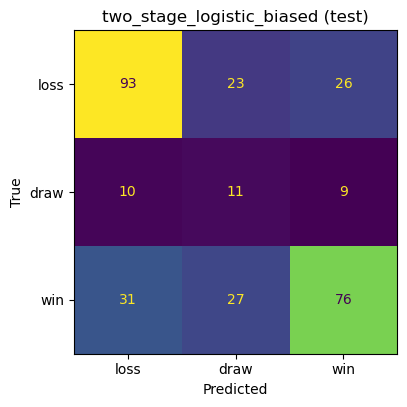

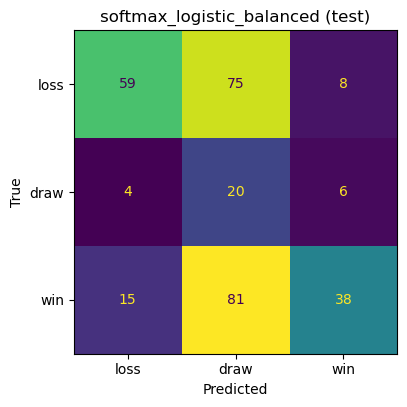

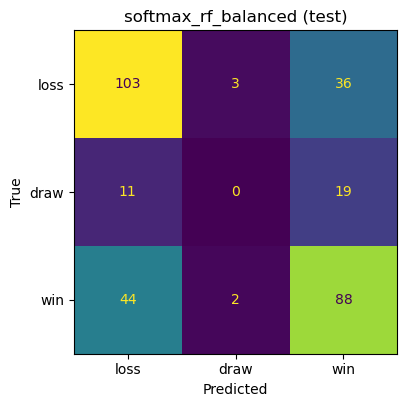

In [10]:
# Diagnostics: reports + confusion matrices on test.

results_df = pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

pred_test_2stage = np.argmax(p_test_2stage, axis=1)
pred_test_soft = np.argmax(p_test_soft, axis=1)
pred_test_rf = np.argmax(p_test_rf, axis=1)

print("Two-stage (test) classification report")
print(classification_report(y_test, pred_test_2stage, target_names=CLASS_NAMES, zero_division=0))

plot_cm(y_test, pred_test_2stage, "two_stage_logistic_biased (test)")
plot_cm(y_test, pred_test_soft, "softmax_logistic_balanced (test)")
plot_cm(y_test, pred_test_rf, "softmax_rf_balanced (test)")


In [11]:
# Bayesian softmax benchmark (optional).
RUN_BAYES_QUICK = False

if RUN_BAYES_QUICK:
    try:
        import pymc as pm
        import arviz as az
    except Exception as exc:
        print("Skipping Bayesian softmax: PyMC/ArviZ not available.", exc)
    else:
        scaler_b = StandardScaler()
        X_train_b = scaler_b.fit_transform(X_train.values)
        X_val_b = scaler_b.transform(X_val.values)
        X_test_b = scaler_b.transform(X_test.values)

        coords = {"feature": feature_cols, "class": CLASS_NAMES}

        with pm.Model(coords=coords) as bayes_softmax:
            X_data = pm.Data("X_data", X_train_b)
            y_data = pm.Data("y_data", y_train)

            sigma_beta = pm.HalfNormal("sigma_beta", sigma=1.0)
            alpha = pm.Normal("alpha", mu=0.0, sigma=1.0, dims="class")
            beta = pm.Normal("beta", mu=0.0, sigma=sigma_beta, dims=("feature", "class"))

            logits_raw = alpha + pm.math.dot(X_data, beta)
            logits = logits_raw - logits_raw.mean(axis=1, keepdims=True)
            p = pm.Deterministic("p", pm.math.softmax(logits, axis=1))
            pm.Categorical("y_obs", p=p, observed=y_data)

            idata = pm.sample(
                draws=500,
                tune=500,
                chains=2,
                target_accept=0.9,
                random_seed=RANDOM_STATE,
                return_inferencedata=True,
            )

        def _ppc_mean_prob(ppc, key="p"):
            if hasattr(ppc, "posterior_predictive"):
                return ppc.posterior_predictive[key].mean(dim=("chain", "draw")).values
            arr = np.asarray(ppc[key])
            return arr.mean(axis=0)

        with bayes_softmax:
            pm.set_data({"X_data": X_val_b, "y_data": y_val})
            ppc_val = pm.sample_posterior_predictive(idata, var_names=["p"], random_seed=RANDOM_STATE)

            pm.set_data({"X_data": X_test_b, "y_data": y_test})
            ppc_test = pm.sample_posterior_predictive(idata, var_names=["p"], random_seed=RANDOM_STATE)

        p_val_b = _ppc_mean_prob(ppc_val, "p")
        p_test_b = _ppc_mean_prob(ppc_test, "p")

        results.append(evaluate_multiclass("bayesian_softmax_quick", y_val, p_val_b, y_test, p_test_b))

        print("Bayesian softmax quick diagnostics:")
        print("R-hat max:", float(az.rhat(idata).to_array().max()))

        display(pd.DataFrame(results).sort_values("val_balanced_accuracy", ascending=False).reset_index(drop=True))
else:
    print("Bayesian softmax benchmark disabled for default run.")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma_beta, alpha, beta]


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: []


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: []


/Users/nicolaspiro/.local/share/mamba/envs/chesscomint/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Bayesian softmax quick diagnostics:
R-hat max: 1.0216747012954737


,model,val_logloss,val_macro_f1,val_accuracy,val_balanced_accuracy,val_draw_recall,test_logloss,test_macro_f1,test_accuracy,test_balanced_accuracy,test_draw_recall
0,two_stage_logistic_biased,1.003736,0.469915,0.571895,0.477553,0.24,0.993418,0.512026,0.588235,0.529587,0.366667
1,softmax_rf_balanced,0.848270,0.451878,0.653595,0.471555,0.00,0.875418,0.440682,0.624183,0.460690,0.000000
2,bayesian_softmax_quick,0.820258,0.432319,0.624183,0.451614,0.00,0.836036,0.444024,0.633987,0.468152,0.000000
3,softmax_logistic_balanced,1.123723,0.365816,0.369281,0.420740,0.56,1.108419,0.379714,0.382353,0.455247,0.666667


## Conlcusions

Final model choice:

- `two_stage_logistic_biased`

Selection rationale:

- best test balanced accuracy among current finalists
- materially improved draw recall versus most one-stage baselines
- explicit decomposition that matches the observed difficulty of the draw class